# CDF comparison of ERA5 and CMIP model outputs
by sorting the output in order of decreasing discharge, we can easily make a cummalative distribution. By taking the difference of these functions we derive a (very simple) bias correction function that can later be used to bias-correct the future model output when forced with CMIP projections.

In [1]:
# General python
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import json
from collections import defaultdict
from scipy.interpolate import interp1d

# Niceties
from rich import print

In [2]:
# General eWaterCycle
import ewatercycle
import ewatercycle.forcing

In [3]:
# For MEV
from scipy.stats import genextreme, gumbel_r, weibull_min

In [4]:
# Parameters, these get changed when running on HPC
settings_path = "settings.json"

In [5]:
# Parameters
settings_path = "regions/czech_republic/lamah_322/settings.json"


In [6]:
# Load settings
# Read from the JSON file
with open(settings_path, "r") as json_file:
    settings = json.load(json_file)

In [7]:
display(settings)

{'caravan_id': 'lamah_322',
 'country': 'czech_republic',
 'calibration_start_date': '1994-08-01T00:00:00Z',
 'calibration_end_date': '2004-07-31T00:00:00Z',
 'validation_start_date': '2004-08-01T00:00:00Z',
 'validation_end_date': '2014-07-31T00:00:00Z',
 'future_start_date': '2029-08-01T00:00:00Z',
 'future_end_date': '2049-08-31T00:00:00Z',
 'CMIP_info': {'dataset': ['MPI-ESM1-2-LR'],
  'ensembles': ['r1i1p1f1', 'r2i1p1f1', 'r3i1p1f1'],
  'experiments': ['historical', 'ssp126', 'ssp245', 'ssp370', 'ssp585'],
  'project': 'CMIP6',
  'grid': 'gn'},
 'koppen_raster_path': '/home/ewater-mmelotto/koppen_geiger/1991_2020/koppen_geiger_0p00833333.tif',
 'base_path': '/project/ewater/Data/ewatercycleClimateImpact/HBV',
 'path_caravan': '/project/ewater/Data/ewatercycleClimateImpact/HBV/forcing_data/czech_republic/lamah_322/caravan',
 'path_ERA5': '/project/ewater/Data/ewatercycleClimateImpact/HBV/forcing_data/czech_republic/lamah_322/ERA5',
 'path_DestinE': '/project/ewater/Data/ewatercycle

In [8]:
# Open the output of the historic model and CMIP runs
xr_historic = xr.open_dataset(Path(settings['path_output']) / (settings['caravan_id'] + '_historic_output.nc'))

In [9]:
# Open the output of the LeakyBucket historic runs
xr_lb_historic = xr.open_dataset(Path(settings['path_output']) / (settings['caravan_id'] + '_LB_historic_output.nc'))

In [10]:
display(xr_historic)

display(xr_lb_historic)

<xarray.Dataset> Size: 263kB
Dimensions:                                                             (
                                                                         time: 7305)
Coordinates:
  * time                                                                (time) datetime64[ns] 58kB ...
Data variables:
    modelled historic discharge, forcing: CMIP6,MPI-ESM1-2-LR,r1i1p1f1  (time) float64 58kB ...
    modelled historic discharge, forcing: ERA5                          (time) float64 58kB ...
    modelled historic discharge, forcing: DestinE                       (time) float64 58kB ...
    observed Q Caravan                                                  (time) float32 29kB ...
Attributes:
    units:    mm/d

<xarray.Dataset> Size: 263kB
Dimensions:                                             (time: 7305)
Coordinates:
  * time                                                (time) datetime64[ns] 58kB ...
Data variables:
    LB historic, forcing: ERA5                          (time) float64 58kB ...
    LB historic, forcing: CMIP6,MPI-ESM1-2-LR,r1i1p1f1  (time) float64 58kB ...
    LB historic, forcing: DestinE                       (time) float64 58kB ...
    observed Q Caravan                                  (time) float32 29kB ...
Attributes:
    units:    mm/d

In [11]:
def get_var_style(var_name, all_var_names):
    """Return {'color', 'linestyle', 'linewidth'} for a variable based on its name.

    Colour scheme
    -------------
    Observed Caravan     : #000000 black, solid
    ERA5 historical      : #1f77b4 strong blue, solid
    DestinE historical   : #00BCD4 cyan-blue, solid
    CMIP6 hist members   : blue shades, dashed (one shade per member)
    SSP1-2.6             : #2ca02c green
    SSP2-4.5             : #bcbd22 yellow-green
    SSP3-7.0 (CMIP)      : #ff7f0e orange
    SSP5-8.5             : #d62728 red
    DestinE SSP3-7.0     : #9467bd purple, dashed
    Ensemble members of the same scenario share a colour, linestyle varies per member.
    """
    LINESTYLES      = ["-", "--", ":", "-."]
    CMIP_HIST_BLUES = ["#4393c3", "#2166ac", "#92c5de", "#053061"]
    SSP_COLORS      = {
        "ssp126": "#2ca02c",
        "ssp245": "#bcbd22",
        "ssp370": "#ff7f0e",
        "ssp585": "#d62728",
    }

    vl = var_name.lower()

    # Observation
    if "observed" in vl or "caravan" in vl:
        return {"color": "#000000", "linestyle": "-", "linewidth": 2}

    # DestinE future — check before generic SSP so "destine ssp370" is caught first
    if "destine" in vl and any(s in vl for s in ["ssp", "future"]):
        return {"color": "#9467bd", "linestyle": "--", "linewidth": 1.5}

    # Future CMIP — colour by scenario, linestyle varies per ensemble member
    for ssp, color in SSP_COLORS.items():
        if ssp in vl:
            members = [v for v in all_var_names
                       if ssp in v.lower() and "destine" not in v.lower()]
            idx = members.index(var_name) if var_name in members else 0
            return {"color": color,
                    "linestyle": LINESTYLES[idx % len(LINESTYLES)],
                    "linewidth": 1.5}

    # ERA5 historical
    if "era5" in vl:
        return {"color": "#1f77b4", "linestyle": "-", "linewidth": 2}

    # DestinE historical
    if "destine" in vl:
        return {"color": "#00BCD4", "linestyle": "-", "linewidth": 1.5}

    # CMIP6 historical — blue shade per ensemble member
    cmip_hist = [v for v in all_var_names
                 if "cmip" in v.lower()
                 and not any(s in v.lower() for s in ["ssp", "observed"])]
    if var_name in cmip_hist:
        idx = cmip_hist.index(var_name)
        return {"color": CMIP_HIST_BLUES[idx % len(CMIP_HIST_BLUES)],
                "linestyle": "--", "linewidth": 1.5}

    return {"color": "gray", "linestyle": "-", "linewidth": 1}

def calculate_mev(ds, dist_type='gev'):
    """
    Calculate MEV-based return periods for all data variables in an xarray.Dataset.

    Parameters:
    - ds: xarray.Dataset
    - dist_type: str, one of ['gev', 'gumbel', 'weibull']

    Returns:
    - xarray.Dataset with MEV return periods
    """
    mev_distributions = {}
    X_VAR = "observed Q Caravan"

    for var in ds.data_vars:
        s = ds[var].dropna(dim="time")
        years = np.unique(s['time.year'].values)
        annual_params = []
        for year in years:
            # values = valid_ds[var].sel(time=str(year)).values
            values = s.sel(time=str(year)).values
            if len(values) > 0:
                if dist_type == 'gev':
                    params = genextreme.fit(values)
                    dist_func = genextreme
                elif dist_type == 'gumbel':
                    params = gumbel_r.fit(values)
                    dist_func = gumbel_r
                elif dist_type == 'weibull':
                    params = weibull_min.fit(values)
                    dist_func = weibull_min
                else:
                    raise ValueError("dist_type must be one of ['gev', 'gumbel', 'weibull']")
                annual_params.append(params)

        x_vals = np.linspace(float(s.min()), float(s.max()), 1000)
        cdfs = [dist_func.cdf(x_vals, *params) for params in annual_params]
        mean_cdf = np.mean(cdfs, axis=0)
        return_period = 1 / (1 - mean_cdf)
        mev_distributions[var] = (x_vals, return_period)

    if X_VAR in mev_distributions:
        shared_x = mev_distributions[X_VAR][0]
    else:
        shared_x = list(mev_distributions.values())[0][0]

    data_vars = {}
    for var, (x_vals, rp) in mev_distributions.items():
        data_vars[var]         = (("i",), rp)
        data_vars[f"{var}__q"] = (("i",), x_vals)

    mev_ds = xr.Dataset(
        data_vars,
        coords={"i": np.arange(len(shared_x)), "x": (("i",), shared_x)},
        attrs=ds.attrs,
    )
    return mev_ds


def plot_mev(*mev_datasets, dist_type='gev', model_name="", labels=None, save_dir=None):
    """
    Plot MEV curves from one or more xarray.Dataset objects created by calculate_mev().

    Parameters:
    - mev_datasets: one or more xarray.Dataset objects
    - dist_type: str, name of the distribution used (for plot title)
    - model_name: str, model name shown in the plot title
    - labels: list of str, optional prefix labels for each dataset
    """
    suffix = f" — {model_name}" if model_name else ""
    # Collect all variable names across datasets for consistent colour assignment
    all_vars = [var for mev_ds in mev_datasets for var in mev_ds.data_vars if not var.endswith("__q")]

    plt.figure(figsize=(10, 6))
    for i, mev_ds in enumerate(mev_datasets):
        prefix = f"{labels[i]} - " if labels else ""
        for var in mev_ds.data_vars:
            if var.endswith("__q"):
                continue
            s = get_var_style(var, all_vars)
            plt.plot(mev_ds[var].values, mev_ds[f"{var}__q"].values,
                     label=f"{prefix}{var}",
                     color=s["color"], linestyle=s["linestyle"], linewidth=s["linewidth"])

    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Return Period (years)")
    plt.ylabel("Discharge (mm/d)")
    plt.title(f"Metastatistical Extreme Value (MEV) Estimates — {dist_type.upper()} Fit{suffix}")
    plt.legend()
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)
    plt.tight_layout()

    if save_dir:
        filename = f"mev_{dist_type}{'_' + model_name.replace(' ', '_') if model_name else ''}.png"
        filepath = Path(save_dir) / filename
        plt.savefig(filepath, dpi=150, bbox_inches='tight')
        print(f"Saved: {filepath}")

    plt.show()
    plt.close()

def plot_cdf(ds, model_name=""):
    """Plot empirical CDFs and return-period curves for all variables in ds."""
    valid_ds = ds.dropna(dim="time")
    all_vars = list(valid_ds.data_vars)

    sorted_vars = {
        name: np.sort(valid_ds[name].values)[::-1]
        for name in all_vars
    }

    n = len(valid_ds.time)
    cdf_index = np.linspace(0, 1, n)
    return_period_years = np.linspace(n, 1, n) / 365.25

    cdf_ds = xr.Dataset(
        {name: ("cdf", sorted_vars[name]) for name in all_vars},
        coords={"cdf": cdf_index, "return_period": ("cdf", return_period_years)},
    )

    # CDF plot
    plt.figure(figsize=(10, 6))
    for name in cdf_ds.data_vars:
        s = get_var_style(name, all_vars)
        plt.plot(cdf_ds[name], cdf_ds.cdf, label=name,
                 color=s["color"], linestyle=s["linestyle"], linewidth=s["linewidth"])
    plt.ylabel("Cumulative Probability")
    plt.xlabel("Discharge (mm/d)")
    plt.title(f"Empirical CDFs of Discharge Data{' — ' + model_name if model_name else ''}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Return period plot
    plt.figure(figsize=(10, 6))
    for name in cdf_ds.data_vars:
        s = get_var_style(name, all_vars)
        plt.plot(cdf_ds.return_period, cdf_ds[name], label=name,
                 color=s["color"], linestyle=s["linestyle"], linewidth=s["linewidth"])
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Return Period (years)")
    plt.ylabel("Discharge (mm/d)")
    plt.title(f"Return Period Plot of Discharge Data (Log-Log Scale){' — ' + model_name if model_name else ''}")
    plt.legend()
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)
    plt.tight_layout()
    plt.show()

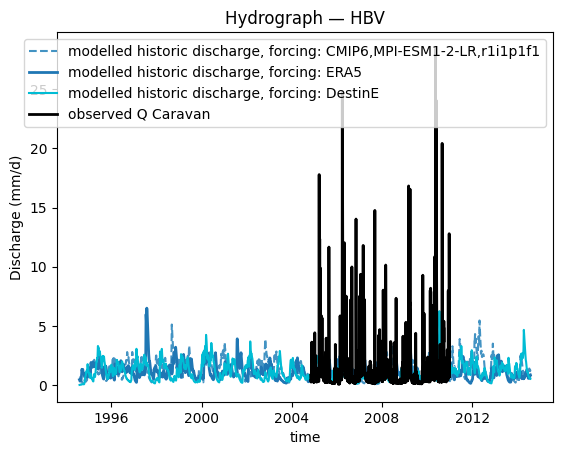

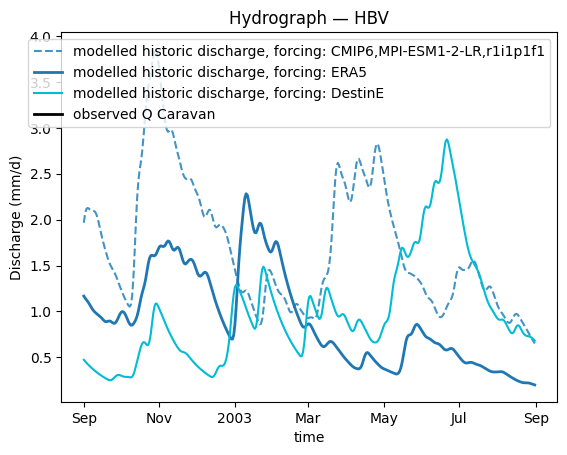

In [12]:
def plot_hydrograph(data_array, model_name=""):
    title = f"Hydrograph{' — ' + model_name if model_name else ''}"
    all_vars = list(data_array.data_vars)
    plt.figure()
    for name in all_vars:
        s = get_var_style(name, all_vars)
        data_array[name].plot(label=name, color=s["color"],
                              linestyle=s["linestyle"], linewidth=s["linewidth"])
    plt.ylabel("Discharge (mm/d)")
    plt.title(title)
    plt.legend()


xr_one_year = xr_historic.sel(time=slice('2002-09-01', '2003-08-31'))

plot_hydrograph(xr_historic, model_name="HBV")
plot_hydrograph(xr_one_year, model_name="HBV")

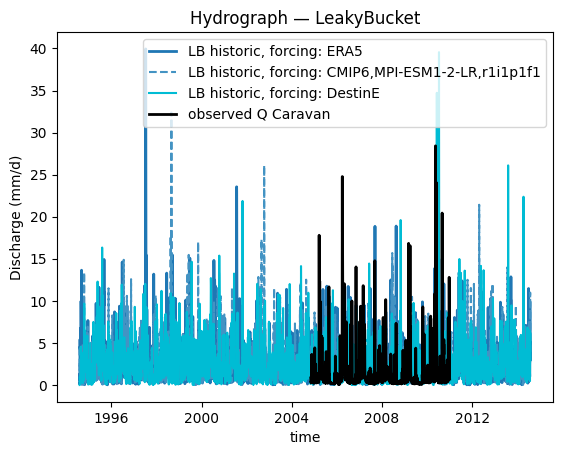

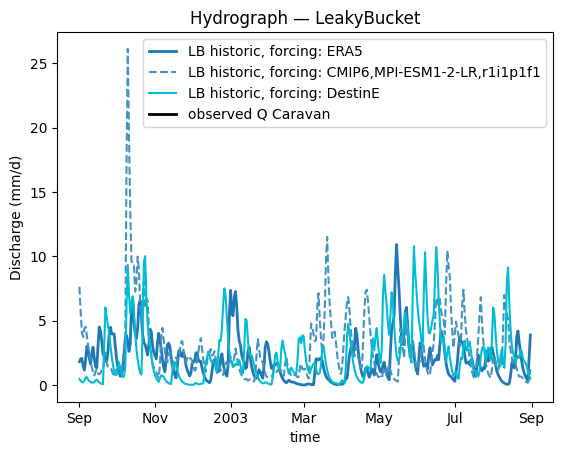

In [13]:
xr_lb_one_year = xr_lb_historic.sel(time=slice('2002-09-01', '2003-08-31'))

plot_hydrograph(xr_lb_historic, model_name="LeakyBucket")
plot_hydrograph(xr_lb_one_year, model_name="LeakyBucket")

In [14]:
distribution_type = 'weibull'

/home/ewater-mmelotto/.local/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:2763: RuntimeWarning: invalid value encountered in power


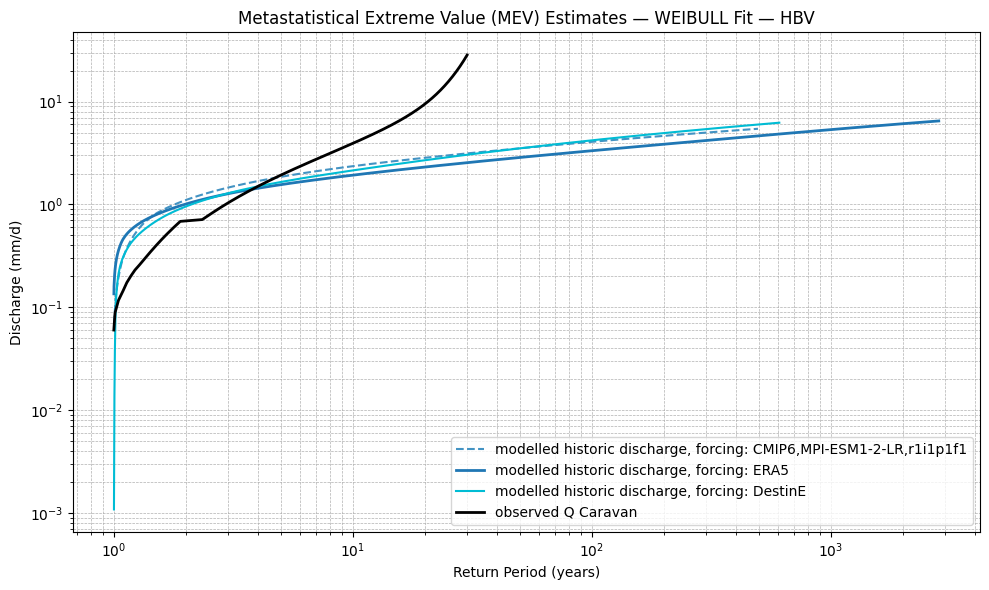

In [15]:
xr_mev_historic = calculate_mev(xr_historic, dist_type=distribution_type)
plot_mev(xr_mev_historic, dist_type=distribution_type, model_name="HBV")

/home/ewater-mmelotto/.local/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:2763: RuntimeWarning: invalid value encountered in power


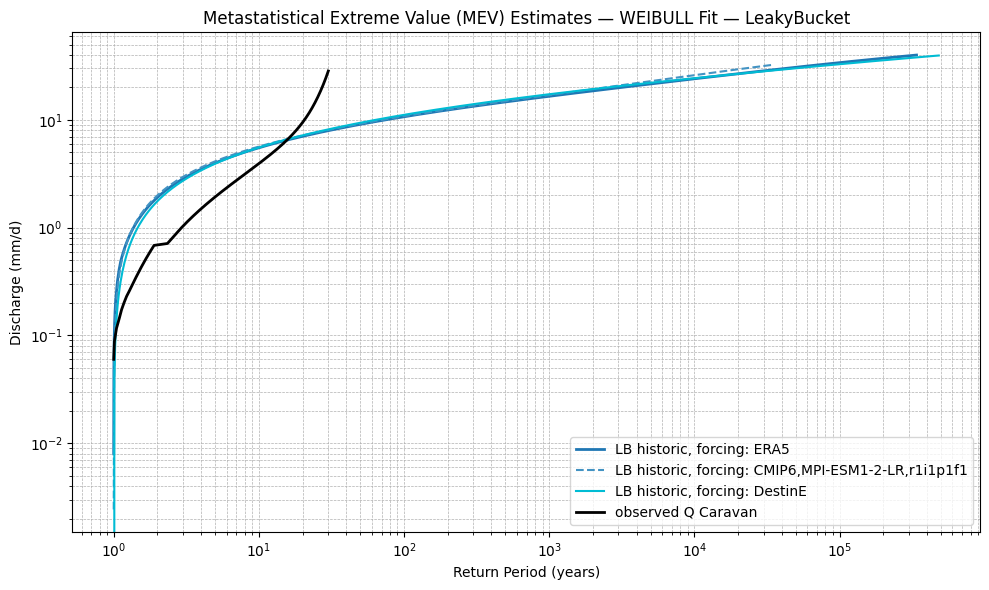

In [16]:
xr_lb_mev_historic = calculate_mev(xr_lb_historic, dist_type=distribution_type)
plot_mev(xr_lb_mev_historic, dist_type=distribution_type, model_name="LeakyBucket")

In [17]:
# Open the output of the historic model and CMIP runs
xr_future = xr.open_dataset(Path(settings['path_output']) / (settings['caravan_id'] + '_future_output.nc'))

In [18]:
xr_future

<xarray.Dataset> Size: 859kB
Dimensions:                                                            (
                                                                        time: 7669)
Coordinates:
  * time                                                               (time) datetime64[ns] 61kB ...
Data variables: (12/13)
    modelled future discharge, forcing: MPI-ESM1-2-LR,ssp126,r1i1p1f1  (time) float64 61kB ...
    modelled future discharge, forcing: MPI-ESM1-2-LR,ssp126,r2i1p1f1  (time) float64 61kB ...
    modelled future discharge, forcing: MPI-ESM1-2-LR,ssp126,r3i1p1f1  (time) float64 61kB ...
    modelled future discharge, forcing: MPI-ESM1-2-LR,ssp245,r1i1p1f1  (time) float64 61kB ...
    modelled future discharge, forcing: MPI-ESM1-2-LR,ssp245,r2i1p1f1  (time) float64 61kB ...
    modelled future discharge, forcing: MPI-ESM1-2-LR,ssp245,r3i1p1f1  (time) float64 61kB ...
    ...                                                                 ...
    modelled future discharge, forcing: MPI-ESM1-2-LR,ssp370,r2i1p1f1  (time) float64 61kB ...
    modelled future discharge, forcing: MPI-ESM1-2-LR,ssp370,r3i1p1f1  (time) float64 61kB ...
    modelled future discharge, forcing: MPI-ESM1-2-LR,ssp585,r1i1p1f1  (time) float64 61kB ...
    modelled future discharge, forcing: MPI-ESM1-2-LR,ssp585,r2i1p1f1  (time) float64 61kB ...
    modelled future discharge, forcing: MPI-ESM1-2-LR,ssp585,r3i1p1f1  (time) float64 61kB ...
    modelled future discharge, forcing: DestinE,IFS-FESOM,ssp370       (time) float64 61kB ...
Attributes:
    units:    mm/d

In [19]:
# Open the output of the LeakyBucket historic runs
xr_lb_future = xr.open_dataset(Path(settings['path_output']) / (settings['caravan_id'] + '_LB_future_output.nc'))

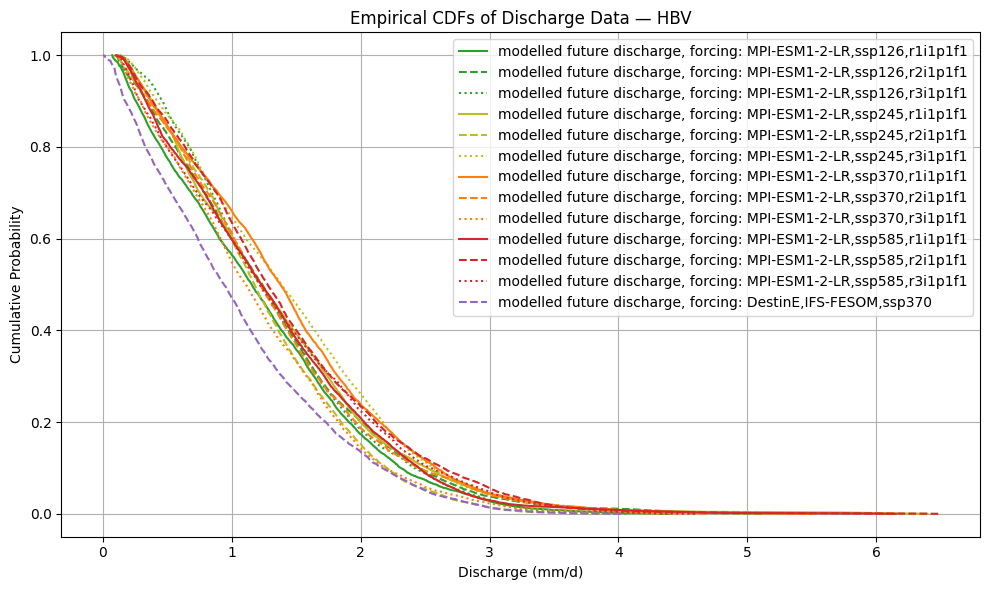

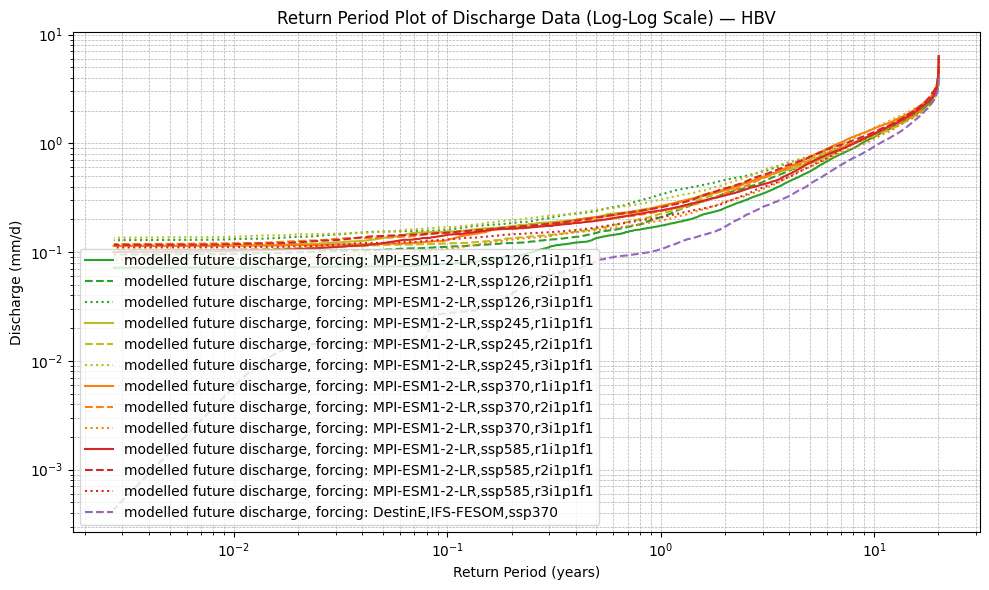

In [20]:
plot_cdf(xr_future, model_name="HBV")

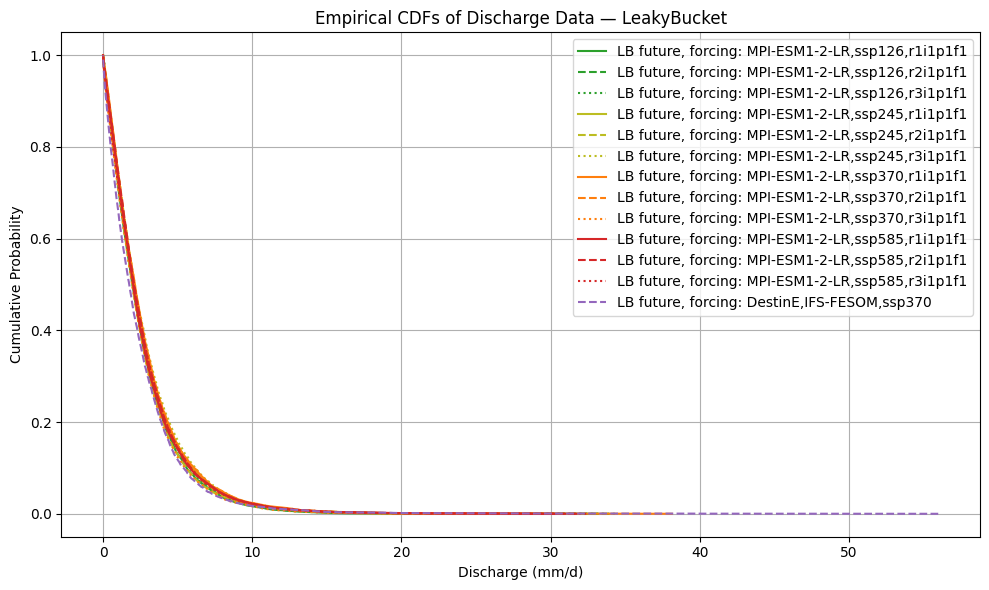

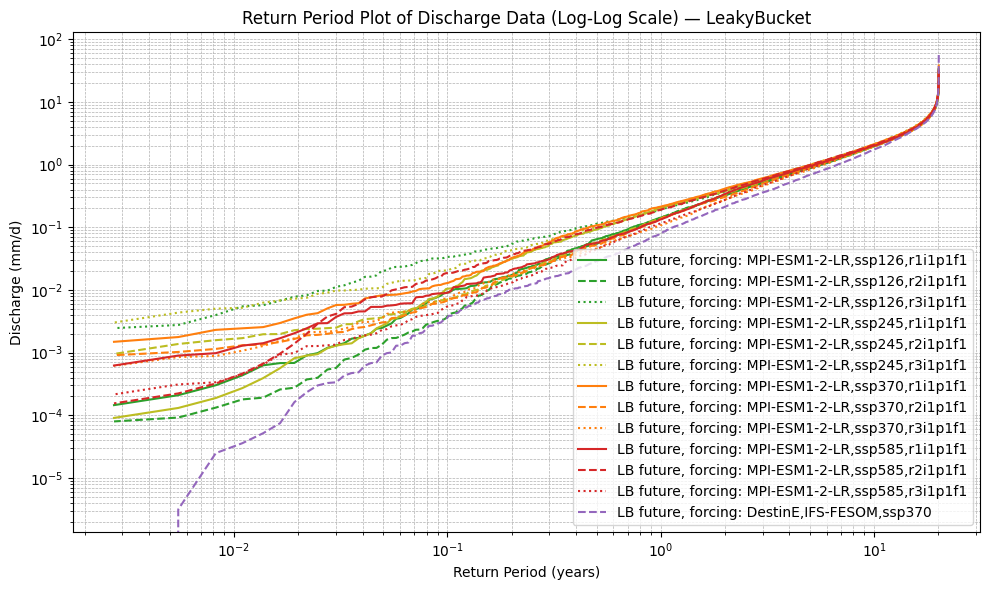

In [21]:
plot_cdf(xr_lb_future, model_name="LeakyBucket")

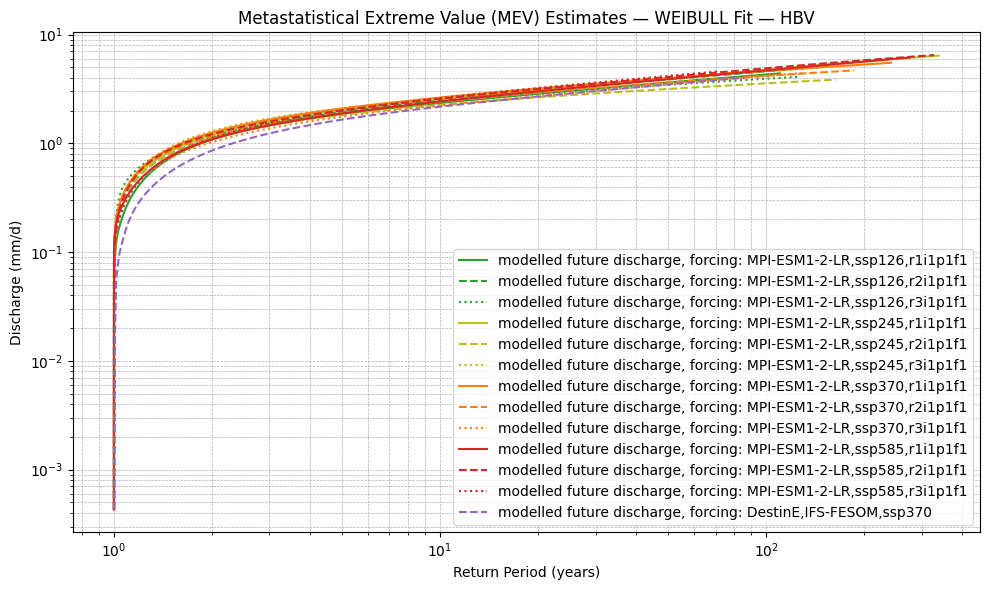

In [22]:
xr_mev_future = calculate_mev(xr_future, dist_type=distribution_type)
plot_mev(xr_mev_future, dist_type=distribution_type, model_name="HBV")

/home/ewater-mmelotto/.local/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:2763: RuntimeWarning: invalid value encountered in power


/home/ewater-mmelotto/.local/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:2763: RuntimeWarning: invalid value encountered in power


/home/ewater-mmelotto/.local/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:2763: RuntimeWarning: invalid value encountered in power


/home/ewater-mmelotto/.local/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:2763: RuntimeWarning: invalid value encountered in power


/home/ewater-mmelotto/.local/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:2763: RuntimeWarning: invalid value encountered in power


...

/home/ewater-mmelotto/.local/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:2763: RuntimeWarning: invalid value encountered in power


/home/ewater-mmelotto/.local/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:2763: RuntimeWarning: invalid value encountered in power


/home/ewater-mmelotto/.local/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:2763: RuntimeWarning: invalid value encountered in power


/home/ewater-mmelotto/.local/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:2763: RuntimeWarning: invalid value encountered in power


/home/ewater-mmelotto/.local/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:2763: RuntimeWarning: invalid value encountered in power


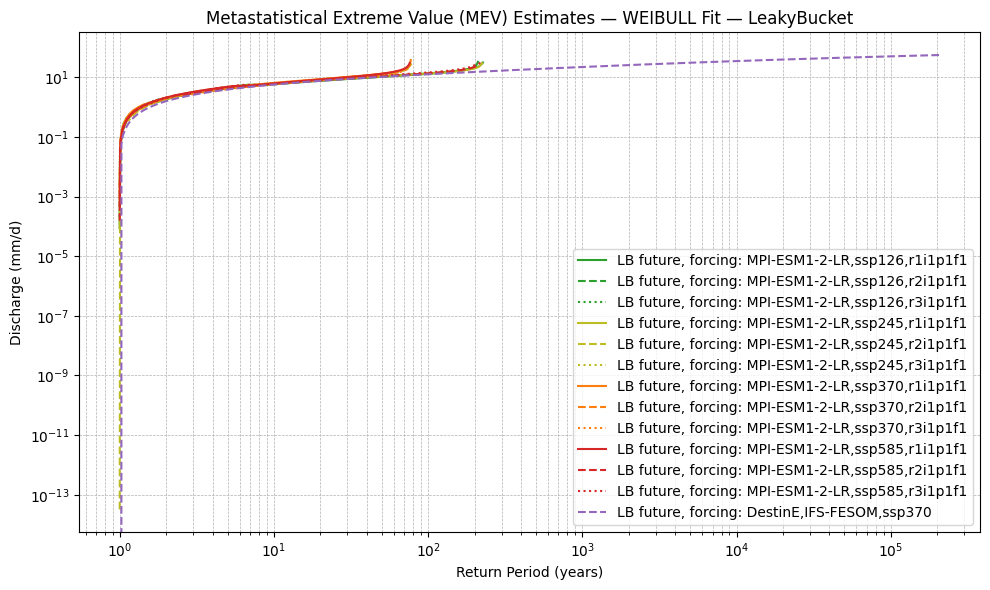

In [23]:
xr_lb_mev_future = calculate_mev(xr_lb_future, dist_type=distribution_type)
plot_mev(xr_lb_mev_future, dist_type=distribution_type, model_name="LeakyBucket")

Saved: regions/czech_republic/lamah_322/figures/mev_weibull_HBV.png

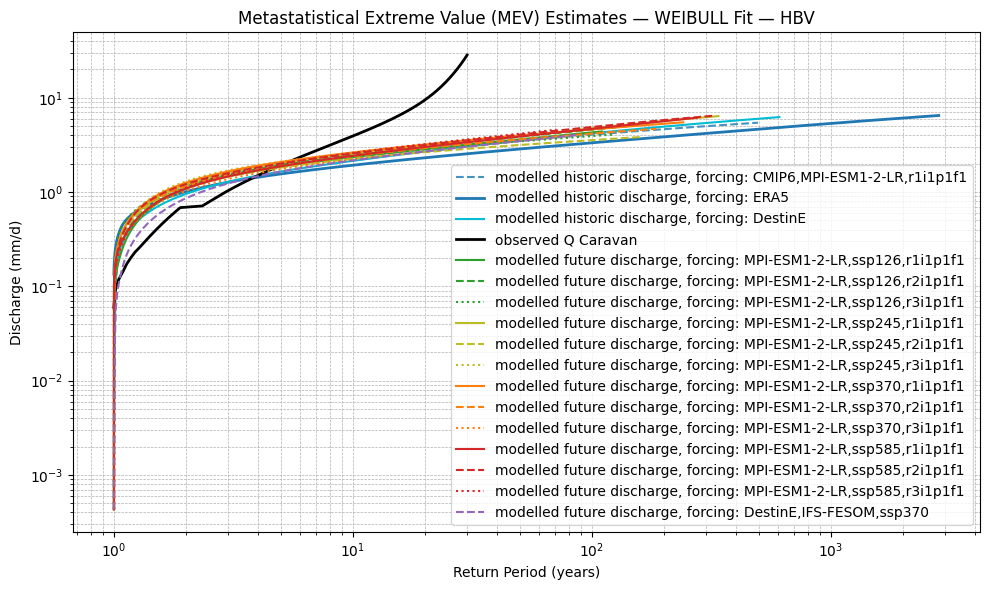

In [24]:
plot_mev(xr_mev_historic, xr_mev_future, model_name="HBV", dist_type=distribution_type, save_dir=Path(settings["figure_output"]))

Saved: regions/czech_republic/lamah_322/figures/mev_weibull_LeakyBucket.png

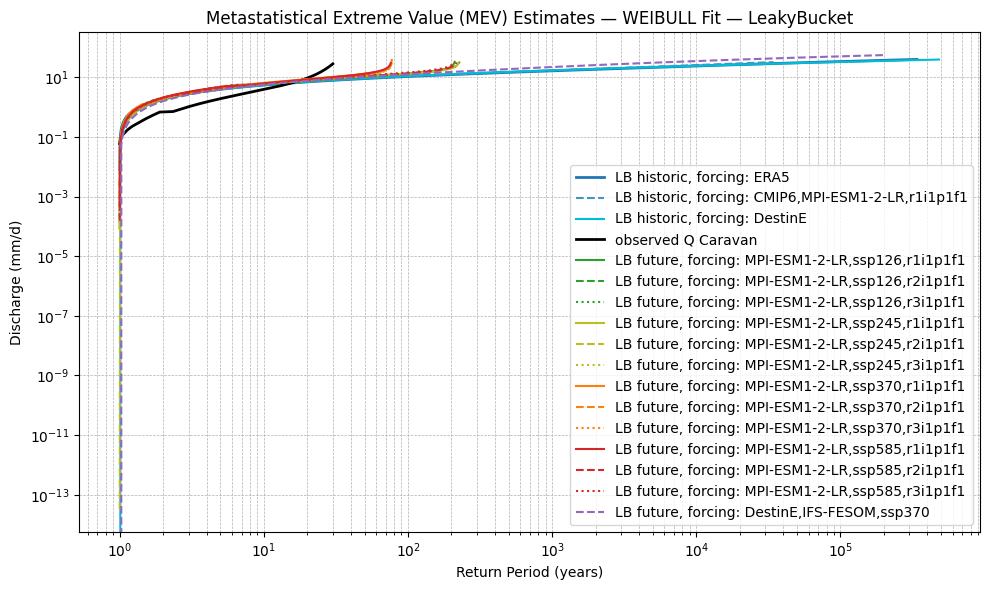

In [25]:
plot_mev(xr_lb_mev_historic, xr_lb_mev_future, model_name="LeakyBucket", dist_type=distribution_type, save_dir=Path(settings["figure_output"]))

## Get return periods

In [26]:
def get_reference_discharge(mev_ds, obs_var, return_period_yr):
    q  = mev_ds[f"{obs_var}__q"].values
    rp = mev_ds[obs_var].values
    sort_idx = np.argsort(rp)
    f = interp1d(rp[sort_idx], q[sort_idx], fill_value="extrapolate")
    return float(f(return_period_yr))

def get_return_period_at_discharge(mev_ds, discharge):
    result = {}
    for var in mev_ds.data_vars:
        if var.endswith("__q"):
            continue
        q  = mev_ds[f"{var}__q"].values
        rp = mev_ds[var].values
        sort_idx = np.argsort(q)
        f = interp1d(q[sort_idx], rp[sort_idx], fill_value="extrapolate")
        result[var] = float(f(discharge))
    return result

def _build_rp_dict(mev_hist_ds, mev_fut_ds, obs_q100, obs_q1000, obs_var=None):
    """Build a return-period result dict for one model (HBV or LeakyBucket)."""
    rp_dict = {
        "observed_reference": {
            "q100_mm_d": round(obs_q100, 4),
            "q1000_mm_d": round(obs_q1000, 4),
        }
    }

    # --- Historic ---
    hist_rp_at_q100  = get_return_period_at_discharge(mev_hist_ds, obs_q100)
    hist_rp_at_q1000 = get_return_period_at_discharge(mev_hist_ds, obs_q1000)

    for var in hist_rp_at_q100:
        var_lower = var.lower()
        if obs_var and "observed" in var_lower:
            continue
        elif "era5" in var_lower:
            label = "ERA5"
        elif "destine" in var_lower:
            label = "DestinE_historical"
        else:
            label = var
        rp_dict[label] = {
            "rp_at_obs_q100":  round(hist_rp_at_q100[var],  2),
            "rp_at_obs_q1000": round(hist_rp_at_q1000[var], 2),
        }

    # --- Future ---
    fut_rp_at_q100  = get_return_period_at_discharge(mev_fut_ds, obs_q100)
    fut_rp_at_q1000 = get_return_period_at_discharge(mev_fut_ds, obs_q1000)

    scenario_rp100  = defaultdict(list)
    scenario_rp1000 = defaultdict(list)

    for var in fut_rp_at_q100:
        var_lower = var.lower()
        if "destine" in var_lower:
            scenario_rp100["DestinE_future"].append(fut_rp_at_q100[var])
            scenario_rp1000["DestinE_future"].append(fut_rp_at_q1000[var])
            continue
        for ssp in ["ssp126", "ssp245", "ssp370", "ssp585"]:
            if ssp in var_lower:
                scenario_rp100[ssp].append(fut_rp_at_q100[var])
                scenario_rp1000[ssp].append(fut_rp_at_q1000[var])
                break

    for scenario, vals in scenario_rp100.items():
        rp_dict[scenario] = {
            "rp_at_obs_q100":  f"{round(float(np.mean(vals)), 2)} ± {round(float(np.std(vals)), 2)}",
            "rp_at_obs_q1000": f"{round(float(np.mean(scenario_rp1000[scenario])), 2)} ± {round(float(np.std(scenario_rp1000[scenario])), 2)}",
        }

    return rp_dict

In [27]:

# --- Observed reference discharge (from HBV historic which contains observed Q) ---
obs_var = "observed Q Caravan"
obs_q100  = get_reference_discharge(xr_mev_historic, obs_var, 100)
obs_q1000 = get_reference_discharge(xr_mev_historic, obs_var, 1000)

display(f"Observed 100yr discharge: {obs_q100:.2f} mm/d")
display(f"Observed 1000yr discharge: {obs_q1000:.2f} mm/d")

# --- HBV ---
rp_dict_hbv = _build_rp_dict(xr_mev_historic, xr_mev_future,
                              obs_q100, obs_q1000, obs_var=obs_var)

# --- LeakyBucket ---
rp_dict_lb = _build_rp_dict(xr_lb_mev_historic, xr_lb_mev_future,
                             obs_q100, obs_q1000, obs_var=obs_var)

# --- Write to results.json ---
results_path = Path(settings["results_path"])
results = json.loads(results_path.read_text()) if results_path.exists() else {}
results["return_periods_HBV"] = rp_dict_hbv
results["return_periods_leakybucket"] = rp_dict_lb
results_path.write_text(json.dumps(results, indent=4))
print(f"Return periods written to {results_path}")
display(rp_dict_hbv)
display(rp_dict_lb)

'Observed 100yr discharge: 291.86 mm/d'

'Observed 1000yr discharge: 3682.97 mm/d'

Return periods written to regions/czech_republic/lamah_322/results.json

{'observed_reference': {'q100_mm_d': 291.8552, 'q1000_mm_d': 3682.9692},
 'modelled historic discharge, forcing: CMIP6,MPI-ESM1-2-LR,r1i1p1f1': {'rp_at_obs_q100': 158362.37,
  'rp_at_obs_q1000': 2027532.69},
 'ERA5': {'rp_at_obs_q100': 711157.7, 'rp_at_obs_q1000': 9128603.95},
 'DestinE_historical': {'rp_at_obs_q100': 143210.68,
  'rp_at_obs_q1000': 1836338.64},
 'ssp126': {'rp_at_obs_q100': '39379.48 ± 8779.55',
  'rp_at_obs_q1000': '502541.0 ± 111943.78'},
 'ssp245': {'rp_at_obs_q100': '55523.38 ± 25379.85',
  'rp_at_obs_q1000': '709588.6 ± 324565.73'},
 'ssp370': {'rp_at_obs_q100': '55591.83 ± 12959.59',
  'rp_at_obs_q1000': '710479.3 ± 166315.47'},
 'ssp585': {'rp_at_obs_q100': '44212.33 ± 21253.43',
  'rp_at_obs_q1000': '566273.66 ± 273036.18'},
 'DestinE_future': {'rp_at_obs_q100': '23382.04 ± 0.0',
  'rp_at_obs_q1000': '297844.86 ± 0.0'}}

{'observed_reference': {'q100_mm_d': 291.8552, 'q1000_mm_d': 3682.9692},
 'ERA5': {'rp_at_obs_q100': 17240378.95, 'rp_at_obs_q1000': 244755641.27},
 'LB historic, forcing: CMIP6,MPI-ESM1-2-LR,r1i1p1f1': {'rp_at_obs_q100': 1645337.53,
  'rp_at_obs_q1000': 22699926.6},
 'DestinE_historical': {'rp_at_obs_q100': 27663311.96,
  'rp_at_obs_q1000': 393000345.24},
 'ssp126': {'rp_at_obs_q100': '261.9 ± 118.76',
  'rp_at_obs_q1000': '1444.39 ± 791.09'},
 'ssp245': {'rp_at_obs_q100': '198.44 ± 131.46',
  'rp_at_obs_q1000': '1136.34 ± 939.05'},
 'ssp370': {'rp_at_obs_q100': '104.3 ± 9.48',
  'rp_at_obs_q1000': '464.02 ± 133.95'},
 'ssp585': {'rp_at_obs_q100': '304.84 ± 129.84',
  'rp_at_obs_q1000': '2098.84 ± 983.0'},
 'DestinE_future': {'rp_at_obs_q100': '6719084.13 ± 0.0',
  'rp_at_obs_q1000': '100356003.27 ± 0.0'}}